In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ------------------------
# 1. Load the datasets
# ------------------------
train_df = pd.read_csv("./train_ueba.csv", encoding='latin1')
test_df  = pd.read_csv("./test_ueba.csv", encoding='latin1')
     

# Check data
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

# ------------------------
# 2. Preprocessing
# ------------------------

# Drop non-numeric/unnecessary columns if any exist
cols_to_use = ['account', 'group', 'IP', 'url', 'port', 'vlan', 'switchIP', 'time']
target_col = 'ret'  # 'ret' is the risk score in training set

# Convert 'time' to a numerical feature (hour of day)
train_df['hour'] = pd.to_datetime(train_df['time'], errors='coerce').dt.hour
test_df['hour'] = pd.to_datetime(test_df['time'], errors='coerce').dt.hour

# Fill missing values
train_df.fillna('missing', inplace=True)
test_df.fillna('missing', inplace=True)

# Label encode categorical columns
le = LabelEncoder()
for col in ['account', 'group', 'IP', 'url', 'switchIP']:
    combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

# Prepare features and target
X_train = train_df[['account', 'group', 'IP', 'url', 'port', 'vlan', 'switchIP', 'hour']]
y_train = train_df['ret']

X_test = test_df[['account', 'group', 'IP', 'url', 'port', 'vlan', 'switchIP', 'hour']]

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------
# 3. Train Isolation Forest
# ------------------------
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # percentage of anomalies expected
    random_state=42
)
model.fit(X_train_scaled)

# ------------------------
# 4. Predict anomalies
# ------------------------
train_preds = model.predict(X_train_scaled)
test_preds = model.predict(X_test_scaled)

# Convert -1 (anomaly) to 1, 1 (normal) to 0
train_preds = [1 if p == -1 else 0 for p in train_preds]
test_preds = [1 if p == -1 else 0 for p in test_preds]

# ------------------------
# 5. Evaluation Metrics
# ------------------------
# For demonstration, we'll consider high 'ret' values (> threshold) as anomalies
threshold = train_df['ret'].median()
y_true = (train_df['ret'] > threshold).astype(int)

acc = accuracy_score(y_true, train_preds)
prec = precision_score(y_true, train_preds)
rec = recall_score(y_true, train_preds)
f1 = f1_score(y_true, train_preds)
roc = roc_auc_score(y_true, train_preds)

print("\n📊 UEBA Model Performance:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc:.4f}")

# ------------------------
# 6. Save predictions
# ------------------------
test_df['anomaly_flag'] = test_preds
test_df.to_csv("ueba_isolationf_predictions.csv", index=False)
print("\nPredictions saved to 'ueba_isolationf_predictions.csv'")

Training shape: (528690, 10)
Testing shape: (211403, 9)

📊 UEBA Model Performance:
Accuracy: 0.5205
Precision: 0.7043
Recall: 0.0704
F1-Score: 0.1281
ROC-AUC: 0.5204

Predictions saved to 'ueba_isolationf_predictions.csv'


In [12]:
test_df.head(10)

,id,account,group,IP,url,port,vlan,switchIP,time,hour,anomaly_flag
0,1,113,1,80,1040,26616,700,115,2021/6/5 8:31,8,0
1,2,113,1,26,59,17175,700,34,2021/6/15 6:05,6,0
2,3,113,1,23,778,33385,700,57,2021/5/10 6:42,6,0
3,4,113,1,125,1239,11188,700,27,2021/5/18 7:50,7,0
4,5,113,1,67,881,15788,700,115,2021/6/17 8:09,8,0
5,6,113,1,91,54,16128,700,92,2021/5/18 7:01,7,0
6,7,113,1,91,1258,22383,700,92,2021/6/7 4:22,4,0
7,8,113,1,24,1314,27656,700,108,2021/5/17 9:02,9,0
8,9,113,1,115,1133,16128,700,15,2021/6/2 8:08,8,0
9,10,113,1,101,254,14146,700,126,2021/6/1 7:45,7,0


In [13]:
train_df.head(10)

,id,account,group,IP,url,port,vlan,switchIP,time,ret,hour
0,1,113,1,18,216,15788,700,44,2021/6/16 7:56,0.1149,7
1,2,113,1,101,157,12665,700,91,2021/6/28 7:58,0.1801,7
2,3,113,1,81,373,25551,700,44,2021/6/1 6:37,0.3690,6
3,4,113,1,39,1136,18274,700,102,2021/5/5 8:18,0.1532,8
4,5,113,1,77,57,34572,700,92,2021/6/20 6:52,0.1449,6
5,6,113,1,13,598,17175,700,102,2021/6/14 7:21,0.3072,7
6,7,113,1,91,613,32342,700,13,2021/6/20 8:19,0.1630,8
7,8,113,1,24,881,16128,700,73,2021/5/27 6:17,0.3238,6
8,9,113,1,39,753,28112,700,13,2021/5/1 6:23,0.1757,6
9,10,113,1,42,1078,34782,700,44,2021/6/20 7:26,0.5223,7


In [14]:
# --- UEBA with XGBoost (Supervised Learning for Insider Threat Detection) ---
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from xgboost import XGBClassifier

# ------------------------
# 1. Load the datasets
# ------------------------
train_df = pd.read_csv("./train_ueba.csv", encoding='latin1')
test_df  = pd.read_csv("./test_ueba.csv", encoding='latin1')

# ------------------------
# 2. Preprocessing
# ------------------------

# Convert time to hour of day
train_df['hour'] = pd.to_datetime(train_df['time'], errors='coerce').dt.hour
test_df['hour']  = pd.to_datetime(test_df['time'], errors='coerce').dt.hour

# Fill missing values
train_df.fillna('missing', inplace=True)
test_df.fillna('missing', inplace=True)

# Label encode categorical columns
le = LabelEncoder()
for col in ['account', 'group', 'IP', 'url', 'switchIP']:
    combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col]  = le.transform(test_df[col].astype(str))

# ------------------------
# 3. Convert ret to binary classification
# ------------------------
# Create label (1 = risky user, 0 = normal)
threshold = train_df['ret'].median()
train_df['label'] = (train_df['ret'] > threshold).astype(int)

# Prepare features and target
X = train_df[['account', 'group', 'IP', 'url', 'port', 'vlan', 'switchIP', 'hour']]
y = train_df['label']

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split training data for internal validation
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# ------------------------
# 4. Train XGBoost model
# ------------------------
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# ------------------------
# 5. Evaluate on validation set
# ------------------------
y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]

acc  = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred)
rec  = recall_score(y_val, y_pred)
f1   = f1_score(y_val, y_pred)
roc  = roc_auc_score(y_val, y_pred_proba)

print("\n📊 UEBA XGBoost Model Performance:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# ------------------------
# 6. Predict on Test Data
# ------------------------
X_test = test_df[['account', 'group', 'IP', 'url', 'port', 'vlan', 'switchIP', 'hour']]
X_test_scaled = scaler.transform(X_test)

test_df['risk_probability'] = model.predict_proba(X_test_scaled)[:, 1]
test_df['predicted_label'] = (test_df['risk_probability'] > 0.5).astype(int)

# Save predictions
test_df.to_csv("ueba_xgboost_predictions.csv", index=False)
print("\nPredictions saved to 'ueba_xgboost_predictions.csv'")


📊 UEBA XGBoost Model Performance:
Accuracy: 0.8393
Precision: 0.8055
Recall: 0.8944
F1-Score: 0.8476
ROC-AUC: 0.9266

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83     52876
           1       0.81      0.89      0.85     52862

    accuracy                           0.84    105738
   macro avg       0.84      0.84      0.84    105738
weighted avg       0.84      0.84      0.84    105738


Predictions saved to 'ueba_xgboost_predictions.csv'


C:\Users\Acer\AppData\Local\Temp\ipykernel_12096\1622914090.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model.feature_importances_, y=X.columns, palette="viridis")


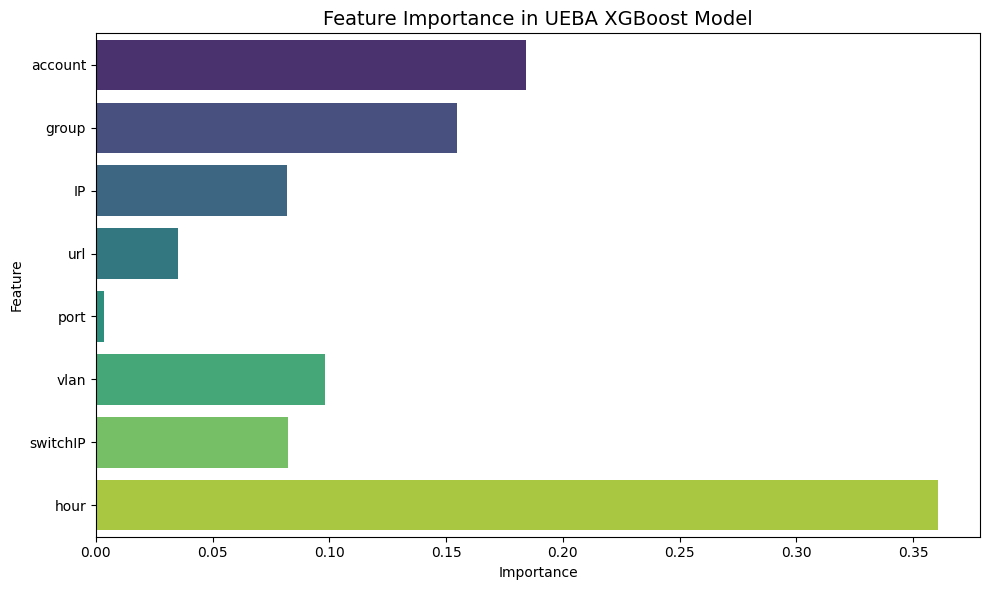

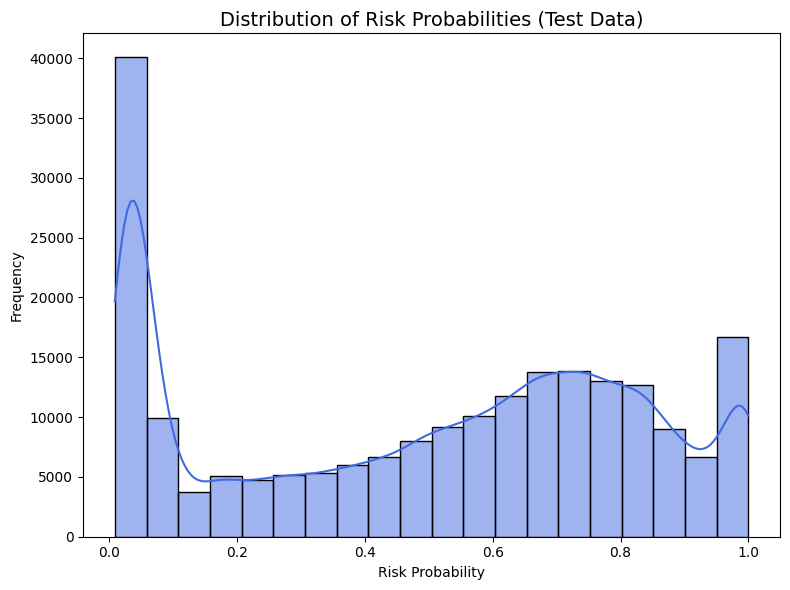

C:\Users\Acer\AppData\Local\Temp\ipykernel_12096\1622914090.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='predicted_label', data=test_df, palette='coolwarm')


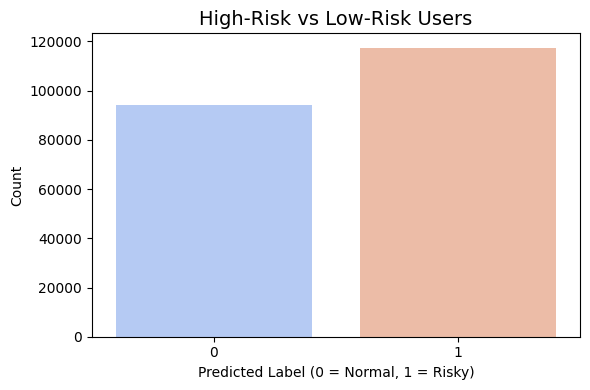

C:\Users\Acer\AppData\Local\Temp\ipykernel_12096\1622914090.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='risk_probability', y='account', data=top_risky, palette='Reds_r')


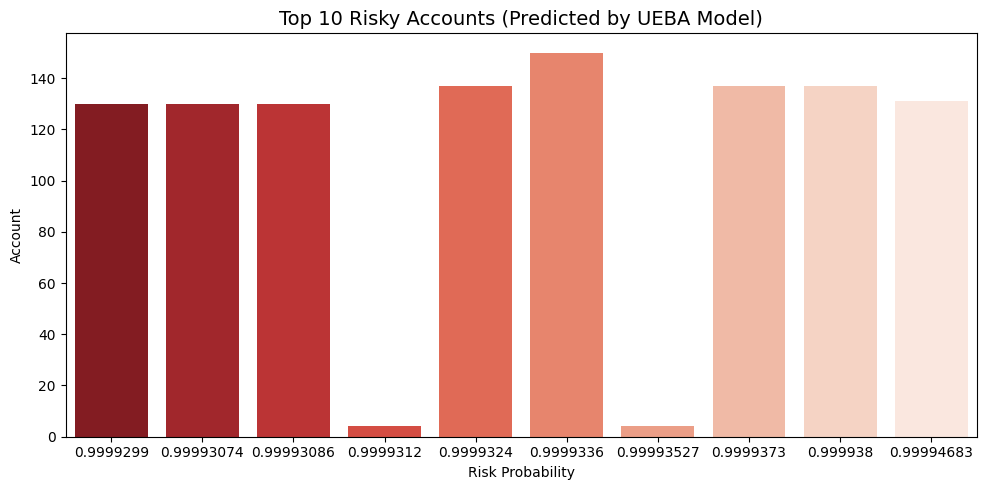

In [15]:
# --- UEBA Visualization Script ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ------------------------
# 1. Load Data
# ------------------------
train_df = pd.read_csv("./train_ueba.csv", encoding='latin1')
test_df  = pd.read_csv("ueba_xgboost_predictions.csv")

# ------------------------
# 2. Prepare Data (same encoding as training)
# ------------------------
train_df['hour'] = pd.to_datetime(train_df['time'], errors='coerce').dt.hour
train_df.fillna('missing', inplace=True)

le = LabelEncoder()
for col in ['account', 'group', 'IP', 'url', 'switchIP']:
    train_df[col] = le.fit_transform(train_df[col].astype(str))

threshold = train_df['ret'].median()
train_df['label'] = (train_df['ret'] > threshold).astype(int)

X = train_df[['account', 'group', 'IP', 'url', 'port', 'vlan', 'switchIP', 'hour']]
y = train_df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# ------------------------
# 3. Feature Importance Visualization
# ------------------------
plt.figure(figsize=(10,6))
sns.barplot(x=model.feature_importances_, y=X.columns, palette="viridis")
plt.title("Feature Importance in UEBA XGBoost Model", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ------------------------
# 4. Risk Distribution in Test Data
# ------------------------
plt.figure(figsize=(8,6))
sns.histplot(test_df['risk_probability'], bins=20, kde=True, color='royalblue')
plt.title("Distribution of Risk Probabilities (Test Data)", fontsize=14)
plt.xlabel("Risk Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ------------------------
# 5. High-Risk vs Low-Risk Counts
# ------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='predicted_label', data=test_df, palette='coolwarm')
plt.title("High-Risk vs Low-Risk Users", fontsize=14)
plt.xlabel("Predicted Label (0 = Normal, 1 = Risky)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ------------------------
# 6. Top 10 Riskiest Accounts
# ------------------------
top_risky = test_df.sort_values(by='risk_probability', ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x='risk_probability', y='account', data=top_risky, palette='Reds_r')
plt.title("Top 10 Risky Accounts (Predicted by UEBA Model)", fontsize=14)
plt.xlabel("Risk Probability")
plt.ylabel("Account")
plt.tight_layout()
plt.show()

